# Análisis de la matriz eléctrica europea mediante clustering

En este cuaderno exploramos los **perfiles de generación eléctrica de distintos países europeos**, 
poniendo el foco en las **similitudes y diferencias de sus mixes energéticos**.

### Metodología

Se trabajó con datasets de la **IEA** para los países de la **UE-27** (21 de los 27 con datos disponibles) correspondientes a las **matrices de generación eléctrica del año 2023**. En una primera instancia se aplicó **k-means**, con el objetivo de obtener **clusters compactos y fácilmente comunicables**, resumidos en centroides que permiten caracterizar rápidamente los perfiles promedio de cada grupo de países. Como complemento, se implementó también una **clusterización jerárquica**. Este método permitió **visualizar la estructura de proximidades paso a paso** y, sobre todo, **resaltar los casos más aislados** que en k-means quedaban forzados dentro de algún cluster aunque sus perfiles fueran atípicos.


### Objetivos
- Analizar la composición de las matrices eléctricas nacionales a partir de distintas fuentes de energía (carbón, gas, nuclear, hidro, renovables variables, etc.).
- Identificar patrones comunes mediante **clustering jerárquico y k-means**.
- Visualizar los resultados con herramientas como **heatmaps, PCA y dendrogramas**.
- Interpretar los clusters en términos de **estrategias de transición energética**: países muy nucleares, sistemas hidro-dependientes, pioneros en eólica/solar, etc.

### Estructura del notebook
1. **Carga y preprocesamiento de datos**  
   Limpieza, normalización y armado de la matriz de features.
2. **Exploración inicial**  
   Heatmaps de correlaciones y distancias entre países.
3. **Clustering jerárquico y k-means**  
   Construcción de dendrogramas y asignación de clusters.
4. **Visualización con PCA**  
   Reducción de dimensionalidad para ver la estructura en 2D.
5. **Interpretación de resultados**  
   Discusión de cada cluster y sus implicancias energéticas.

---

📌 *Este análisis permite entender qué países siguen perfiles energéticos similares, 
cómo se agrupan en función de su dependencia fósil, nuclear o renovable, 
y qué rol ocupan en la transición energética europea.*


In [87]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import seaborn as sns
from adjustText import adjust_text
from IPython.display import display

In [88]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"  
os.environ["OPENBLAS_NUM_THREADS"] = "1" 
os.environ["NUMEXPR_NUM_THREADS"] = "1"
from threadpoolctl import threadpool_limits
threadpool_limits(1)

In [89]:
#Se importaron todos los csvs y se unieron en un único dataframe.
import glob
files = glob.glob("data/*.csv") 
df_list = []

for file in files:
    country = file.split("\\")[-1].replace(".csv", "")
    temp = pd.read_csv(file)
    col_energy = [c for c in temp.columns if "electricity generation" in c.lower()][0]
    temp = temp.rename(columns={col_energy: "Energy_source"})
    temp["Country"] = country
    df_list.append(temp)

df_all = pd.concat(df_list, ignore_index=True)

In [90]:
df_all= df_all[df_all['Year']==2023]
df_all

,Energy_source,Value,Year,Units,Country
23,Coal,1928.0,2023,GWh,Austria
47,Oil,781.0,2023,GWh,Austria
71,Natural gas,7495.0,2023,GWh,Austria
95,Hydro,44523.0,2023,GWh,Austria
119,Biofuels,4188.0,2023,GWh,Austria
...,...,...,...,...,...
4799,Biofuels,5625.0,2023,GWh,The Netherlands
4823,Waste,3787.0,2023,GWh,The Netherlands
4847,Wind,29525.0,2023,GWh,The Netherlands
4871,Solar PV,19578.0,2023,GWh,The Netherlands


In [91]:
df_all = df_all.pivot(index="Country", columns="Energy_source", values="Value").fillna(0)

In [92]:
#Se normalizó el DF para volver comparables las matrices
df_all = df_all.div(df_all.sum(axis=1), axis=0) * 100
df_all

Energy_source,Biofuels,Coal,Geothermal,Hydro,Natural gas,Nuclear,Oil,Other sources,Solar PV,Solar thermal,Tide,Waste,Wind
Country,,,,,,,,,,,,,
Austria,5.624874,2.589484,0.000000,59.798536,10.066483,0.000000,1.048956,0.016117,8.587738,0.000000,0.000000,1.474716,10.793097
Belgium,3.389749,2.189711,0.000000,1.978151,21.860059,39.356234,0.235466,0.494836,9.346911,0.000000,0.000000,2.690524,18.458357
Czechia,6.545540,39.470642,0.000000,4.450707,4.758503,39.494019,0.115586,0.148054,3.755893,0.000000,0.000000,0.350654,0.910401
Denmark,16.344016,7.485696,0.000000,0.056328,2.964632,0.000000,0.708547,0.000000,9.970057,0.000000,0.000000,4.977617,57.493107
Estonia,23.054153,48.929131,0.000000,0.417900,0.365663,0.000000,0.313425,0.000000,12.554414,0.000000,0.000000,2.472575,11.892739
Finland,13.368899,4.142752,0.000000,18.641158,0.809419,42.075055,0.277165,0.295560,0.878097,0.000000,0.000000,1.063282,18.448614
France,1.486146,0.584223,0.024351,11.576034,5.676537,64.339158,1.176437,0.280983,4.151582,0.000000,0.085417,0.824115,9.795018
Germany,7.853989,26.352270,0.038095,4.949793,15.799601,1.409705,1.049465,0.302415,12.420098,0.000000,0.000000,2.369305,27.455263
Greece,1.310306,9.196185,0.000000,8.102260,32.014345,0.000000,9.394534,0.000000,17.817359,0.000000,0.000000,0.084148,22.080862


In [93]:
df_all_grouped = pd.DataFrame()

# Mantenemos carbón separado
df_all_grouped["Coal"] = df_all["Coal"]

# Agrupamos petróleo y gas en "Oil & Gas"
df_all_grouped["Oil & Gas"] = df_all["Oil"] + df_all["Natural gas"]

df_all_grouped["Nuclear"] = df_all["Nuclear"]

# Renovables tradicionales: hidro, biomasa, residuos, geotermia y marea
df_all_grouped["Renewables_trad"] = (
    df_all["Hydro"] + df_all["Biofuels"] + 
    df_all["Waste"] + df_all.get("Geothermal", 0) + df_all.get("Tide", 0)
)

# Renovables variables: viento + solar
df_all_grouped["Renewables_var"] = (
    df_all["Wind"] + df_all["Solar PV"] + df_all.get("Solar thermal", 0)
)

# Otros (incluye mareas y "Other sources" si existen)
df_all_grouped["Other"] = (
    df_all.get("Other sources", 0) 
)

# Conservamos el índice (clusters o países, según lo que tengas)
df_all_grouped.index = df_all.index
df_all=df_all_grouped
df_all

,Coal,Oil & Gas,Nuclear,Renewables_trad,Renewables_var,Other
Country,,,,,,
Austria,2.589484,11.115439,0.000000,66.898126,19.380834,0.016117
Belgium,2.189711,22.095525,39.356234,8.058424,27.805269,0.494836
Czechia,39.470642,4.874089,39.494019,11.346901,4.666294,0.148054
Denmark,7.485696,3.673179,0.000000,21.377961,67.463164,0.000000
Estonia,48.929131,0.679088,0.000000,25.944628,24.447153,0.000000
Finland,4.142752,1.086583,42.075055,33.073338,19.326711,0.295560
France,0.584223,6.852974,64.339158,13.996062,13.946600,0.280983
Germany,26.352270,16.849066,1.409705,15.211182,39.875361,0.302415
Greece,9.196185,41.408880,0.000000,9.496714,39.898221,0.000000


In [94]:
#Se excluyó Other, dado que su carácter marginal en la mayoría de los países no justificaba su inclusión y sólo introducía ruido en el proceso de clusterización.
feature_cols = ["Coal", "Oil & Gas", "Nuclear", "Renewables_trad", "Renewables_var"]
df_all= df_all[feature_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_all)

## Selección del número de clusters (k)

Para determinar k en k-means usamos dos criterios estándar:

- **Elbow (inercia):** mide la suma de distancias cuadráticas de los puntos a su centroide.
  La inercia siempre disminuye al aumentar k; se elige el punto donde la mejora
  adicional se “estanca” (el “codo”).

- **Silhouette:** evalúa qué tan bien quedan separados los clusters (rango -1 a 1).
  Valores más altos indican asignaciones más coherentes y mayor separación entre grupos.

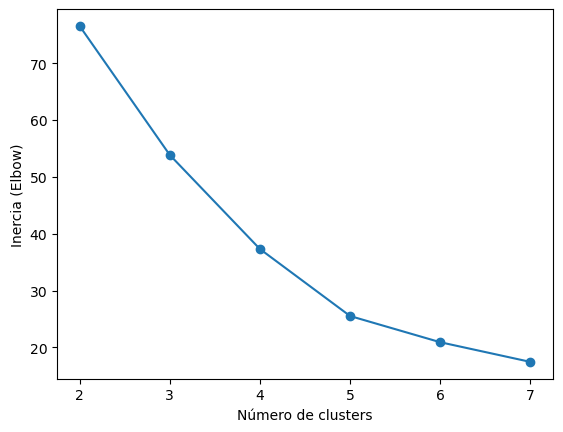

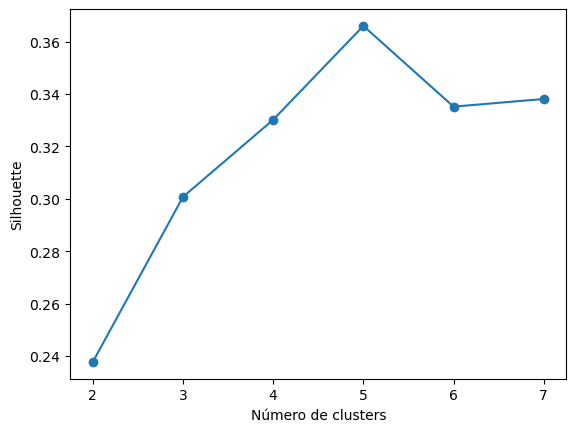

In [95]:
# Criterios de selección de k: Elbow y Silhouette.

inertia = []
silhouette = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init='auto',random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))

plt.plot(K_range, inertia, marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia (Elbow)")
plt.show()

plt.plot(K_range, silhouette, marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette")
plt.show()

**Resultado:** en nuestros datos, el codo se observa alrededor de *k = 4–5* y el promedio de
silhouette es máximo en *k = 5*. Por lo tanto, **adoptamos k = 5** para el modelo principal. También se probaron clusterizaciones con 4 y 6 clusters pero *el mejor resultado fue con k=5*.  


## Metodología de clustering

Se aplicaron dos métodos de agrupamiento con enfoques complementarios:
- **K-means:** asigna cada país a un cluster según la cercanía a un centroide y busca minimizar la varianza interna.
  - *Fortalezas:* rápido, resultados compactos y fáciles de interpretar mediante centroides promedio.
  - *Limitaciones:* requiere definir k a priori y asume clusters aproximadamente esféricos. Esto hace que los **casos atípicos** se integren forzadamente dentro de algún cluster, aunque su perfil energético sea claramente distinto.
  - En este análisis se aplicó k-means sobre el espacio completo de **5 dimensiones** (todas las fuentes energéticas consideradas), ya que ofreció agrupamientos más coherentes en términos de perfiles que al reducir previamente la dimensionalidad. La **reducción a 2 dimensiones mediante PCA** se utilizó únicamente con fines de **visualización** de los clusters y sus centroides.
- **Clustering jerárquico:** construye una jerarquía de similitudes y permite visualizarla mediante un dendrograma.
  - *Fortalezas:* no exige fijar k de entrada, muestra relaciones de proximidad paso a paso, resalta países con perfiles atípicos.
  - *Limitaciones:* Tiene una comunicación más compleja que K-means.
**Estrategia adoptada:**  
K-means se utilizó como método principal por su claridad y comunicación directa, mientras que el jerárquico sirvió de complemento para detectar casos atípicos y validar la robustez de los agrupamientos.

In [96]:
#Clusterización en 5d
pca = PCA(n_components=2, random_state=42)
#Z = pca.fit_transform(X_scaled) #comentado por si se prefiere clusterizar en 2d
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X_scaled)
df_all["Cluster"] = labels
print(df_all[["Cluster"]])


                 Cluster
Country                 
Austria                1
Belgium                2
Czechia                2
Denmark                3
Estonia                0
Finland                2
France                 2
Germany                0
Greece                 4
Hungary                2
Ireland                4
Italy                  4
Latvia                 1
Lithuania              3
Luxembourg             1
Poland                 0
Portugal               3
Slovak Republic        2
Spain                  4
Sweden                 1
The Netherlands        4


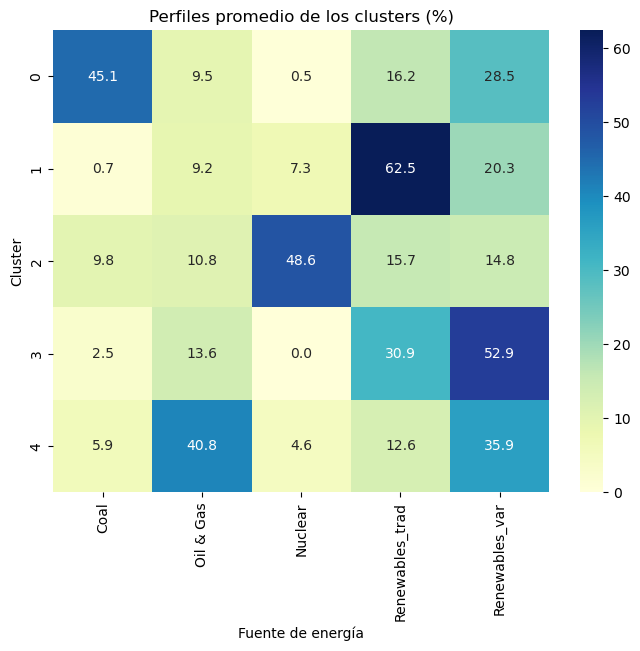

In [97]:
Z = pca.fit_transform(X_scaled)
plot_df = pd.DataFrame({
    "PC1": Z[:,0],
    "PC2": Z[:,1],
    "Cluster": df_all["Cluster"].values,
    "Country": df_all.index
})

profiles = (
    df_all.drop(columns=["Cluster", "Cluster_hier"], errors="ignore")
          .assign(Cluster=df_all["Cluster"])
          .groupby("Cluster").mean()
          .sort_index()
)

# Heatmap de perfiles promedio por cluster
plt.figure(figsize=(8,6))
sns.heatmap(profiles, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Perfiles promedio de los clusters (%)")
plt.ylabel("Cluster")
plt.xlabel("Fuente de energía")
plt.show()

C:\Users\Santiago\AppData\Local\Temp\ipykernel_1752\2341893555.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("tab10")


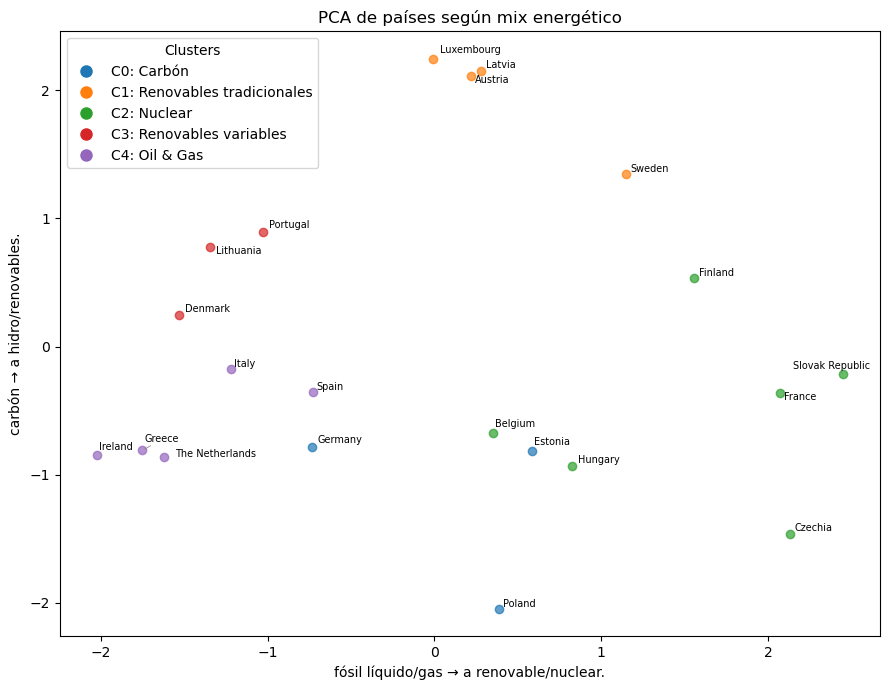

In [98]:
from matplotlib.lines import Line2D
clusters_sorted = np.sort(np.unique(labels))

cluster_labels = {
    0: "C0: Carbón",
    1: "C1: Renovables tradicionales",
    2: "C2: Nuclear",
    3: "C3: Renovables variables",
    4: "C4: Oil & Gas",
}
cmap = plt.cm.get_cmap("tab10")
palette = {c: cmap(i % 10) for i, c in enumerate(sorted(clusters_sorted))}

plt.figure(figsize=(9,7))
# scatter de países
for c in clusters_sorted:
    mask = (labels == c)
    plt.scatter(Z[mask,0], Z[mask,1], alpha=0.7)

# etiquetas de países sin superposición
texts = []
for (x, y), name in zip(Z, df_all.index):
    texts.append(plt.text(x, y, name, fontsize=7))

# autoajuste
adjust_text(texts,
            only_move={'points':'y', 'texts':'y'},  # mueve en vertical para ordenarlos
            arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

legend_elements = []

# proxy por cada cluster
for c in clusters_sorted:
    legend_elements.append(
        Line2D([0], [0], marker='o', linestyle='',
               markerfacecolor=palette[c], markeredgecolor=palette[c],
               markersize=8, label=cluster_labels.get(c, f"C{c}"))
    )

plt.xlabel("fósil líquido/gas → a renovable/nuclear.")
plt.ylabel("carbón → a hidro/renovables.")
plt.title("PCA de países según mix energético")
plt.legend(handles=legend_elements,title="Clusters",loc="upper left")
plt.tight_layout()
plt.show()

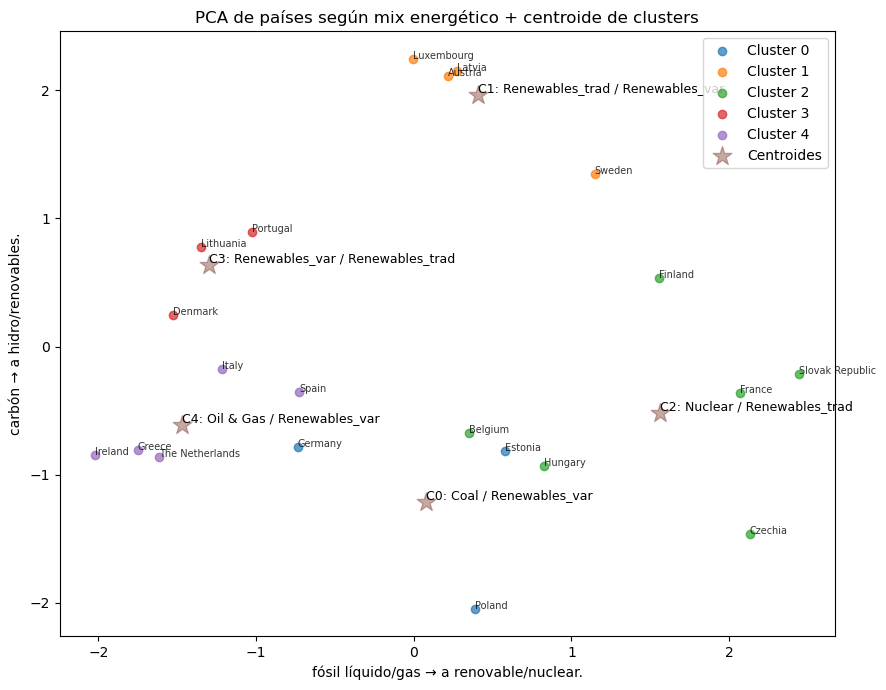

In [99]:
# 1) Matriz de features (sin la col Cluster)
features_df = df_all.drop(columns=["Cluster"], errors="ignore").copy()
feature_names = features_df.columns.tolist()

# 3) PCA 2D
pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(X_scaled)

# 4) Centroides en espacio original-escalado y su proyección al PCA     
labels = df_all["Cluster"].values

centroids = []
for c in clusters_sorted:
    mask = (labels == c)
    centroids.append(X_scaled[mask].mean(axis=0))
centroids = np.vstack(centroids)
centroids_pca = pca.transform(centroids)

# 5) Perfiles promedio por cluster (en % para nombrar centroides)
profiles = (df_all.drop(columns="Cluster")
                  .assign(Cluster=labels)
                  .groupby("Cluster").mean()
                  .sort_index())

# Nombres humanos por top-2 fuentes
topk = 2
centroid_names = []
for c in profiles.index:
    tops = profiles.loc[c].sort_values(ascending=False).head(topk).index.tolist()
    centroid_names.append(" / ".join(tops))

# 6) Scatter: países por cluster + centroides
plt.figure(figsize=(9,7))
for c in clusters_sorted:
    mask = (labels == c)
    plt.scatter(Z[mask,0], Z[mask,1], label=f"Cluster {c}", alpha=0.7)

# centroides (marcador grande tipo X)
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], marker="*", s=200, label="Centroides", alpha=0.5)

# Etiquetas de centroides con top-2 fuentes
for i, c in enumerate(clusters_sorted):
    plt.text(centroids_pca[i,0], centroids_pca[i,1],
             f"C{c}: {centroid_names[i]}",
             fontsize=9, ha="left", va="bottom")

# (Opcional) anotar países — activá si querés ver nombres
annotate_countries = True
if annotate_countries:
    for (x, y), name in zip(Z, df_all.index):
        plt.text(x, y, name, fontsize=7, alpha=0.8)

plt.xlabel("fósil líquido/gas → a renovable/nuclear.")
plt.ylabel("carbón → a hidro/renovables.")
plt.title("PCA de países según mix energético + centroide de clusters")
plt.legend()
plt.tight_layout()
plt.show()


## Caracterización de los clusters

A partir de los perfiles promedio de cada grupo, se pueden resumir las principales características energéticas de los clusters identificados:

- **Cluster 0 → Carbón**  
  Sistemas eléctricos con fuerte dependencia del **carbón** (≈45%), acompañado por una participación secundaria de renovables variables.  
- **Cluster 1 → Renovables tradicionales**  
  Predominio de **hidroeléctrica y biomasa** (≈62%), complementadas con renovables variables. Representa países con matrices muy basadas en fuentes gestionables.  
- **Cluster 2 → Nuclear**  
  Perfil dominado por la **energía nuclear** (≈49%), con presencia secundaria de carbón y otras fuentes. Agrupa a países con una base eléctrica nuclear sólida.  
- **Cluster 3 → Renovables variables**  
  Matrices con peso muy alto de **eólica y solar** (≈53%), acompañadas por renovables tradicionales. Refleja sistemas en transición acelerada hacia renovables intermitentes.  
- **Cluster 4 → Oil & Gas**  
  Predominio de **gas y petróleo** (≈41%), con un aporte importante de renovables variables (≈36%). Muestra una combinación fósil–renovable, dependiente de combustibles fósiles pero con integración creciente de eólica/solar.  
- **Algunos casos atípicos:** Son casos que por la limitación del metódo quedan en un cluster que oculta ciertas caracteristicas particulares del país. 
  *Alemania:* Forma parte del cluster 0 por su alto uso de carbón aunque tenga un alto perfil renovable variable.
  *Suecia:* Integra el cluster 1 por su alto contenido de renovables tradicionales, aunque tenga una matriz muy similar a Finlandia. Sin embargo, esto oculta el perfil núclear del país, lo cual lo acercaría a un cluster con Francia, Chequia o Bélgica. 
---

### Limitaciones de K-means y motivación del análisis jerárquico

El método **K-means** permitió identificar agrupamientos claros y fácilmente comunicables. Sin embargo, presenta limitaciones: al forzar a todos los países a integrarse en algún cluster, termina **ocultando ciertos casos atípicos** o híbridos (por ejemplo, Alemania junto a Polonia y Estonia, o Suecia dentro del bloque de renovables tradicionales).

Para complementar el análisis, se aplicará ahora una **clusterización jerárquica**. Este enfoque no requiere fijar *k* de antemano y permite visualizar la estructura de similitudes de manera progresiva, lo que ayuda a **resaltar mejor los países con perfiles energéticos distintivos** y a validar la robustez de los agrupamientos encontrados.


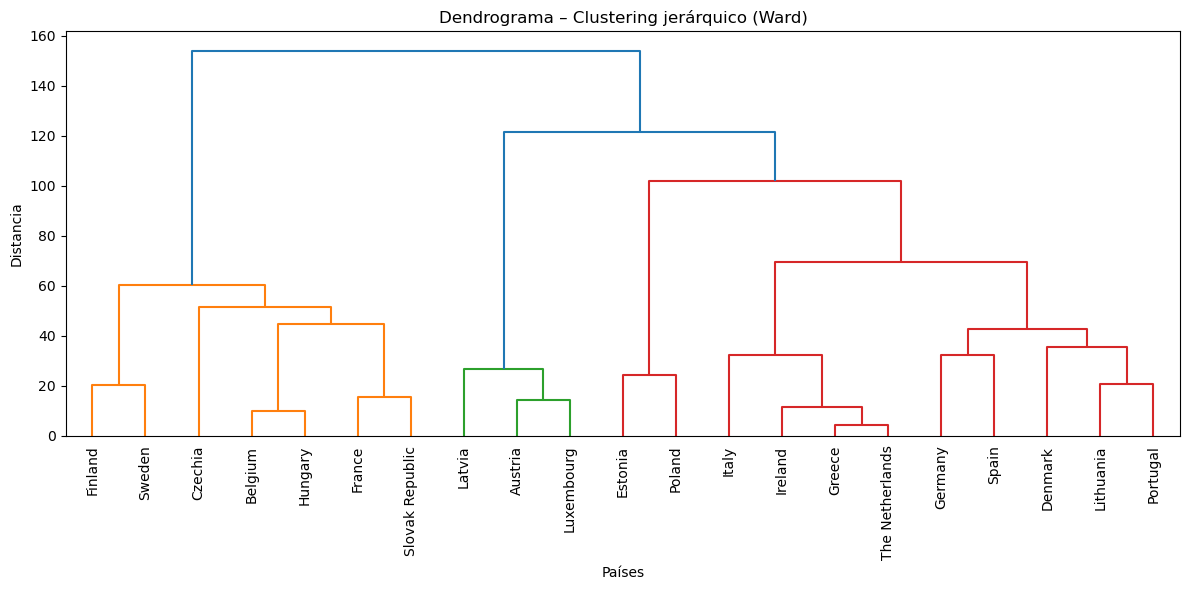

                 Cluster_hier
Country                      
Austria                     2
Belgium                     1
Czechia                     1
Denmark                     5
Estonia                     3
Finland                     1
France                      1
Germany                     5
Greece                      4
Hungary                     1
Ireland                     4
Italy                       4
Latvia                      2
Lithuania                   5
Luxembourg                  2
Poland                      3
Portugal                    5
Slovak Republic             1
Spain                       5
Sweden                      1
The Netherlands             4


In [100]:
X = df_all.drop(columns=["Cluster"], errors="ignore").values

# --- 2. Clustering jerárquico (Ward) ---
Z_link = linkage(X, method='ward')

# --- 3. Graficar dendrograma ---
plt.figure(figsize=(12, 6))
dendrogram(
    Z_link,
    labels=df_all.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=None # o un valor para colorear cortes
)
plt.title("Dendrograma – Clustering jerárquico (Ward)")
plt.xlabel("Países")
plt.ylabel("Distancia")
plt.tight_layout()
plt.show()

# --- 4. Si querés extraer clusters (ej: 6) ---
clusters_hier = fcluster(Z_link, 5,  criterion='maxclust')
df_all["Cluster_hier"] = clusters_hier

print(df_all[["Cluster_hier"]])


In [101]:
comparativa = df_all[["Cluster", "Cluster_hier"]].copy()
comparativa.head()

comparativa["Comentario"] = ""
comparativa.loc["Germany", "Comentario"] = "De fósil a renovables variables"
comparativa.loc["Sweden", "Comentario"] = "Pasó de cluster renovable a cluster nuclear"
comparativa.loc["Poland", "Comentario"] = "Formó un cluster particular junto a Estonia"
comparativa.loc["Estonia", "Comentario"] = "Formó un cluster particular junto a Polonia"

display(comparativa)

,Cluster,Cluster_hier,Comentario
Country,,,
Austria,1,2,
Belgium,2,1,
Czechia,2,1,
Denmark,3,5,
Estonia,0,3,Formó un cluster particular junto a Polonia
Finland,2,1,
France,2,1,
Germany,0,5,De fósil a renovables variables
Greece,4,4,


## Comparación entre K-means y Clustering jerárquico (5 clusters)

Ambos métodos permiten identificar 5 agrupamientos, pero difieren en algunos países clave:

- **Coincidencias generales**  
  - Los bloques principales (Carbón, Nuclear, Renovables tradicionales, Renovables variables, Oil & Gas) aparecen en ambos métodos.  
  - La mayoría de los países mantiene su asignación en el mismo perfil energético.  
- **Diferencias destacadas**  
  - **Alemania:**  
    - *K-means:* cercana a Polonia y Estonia (arrastrada por fósiles).  
    - *Jerárquico:* queda en el mismo cluster que España, Dinamarca y Portugal (más asociado a renovables variables).  
  -  **Polonia y Estonia:**  
    - *K-means:* cercanos a Alemania.  
    - *Jerárquico:* rapidamente forman un cluster separado, mostrando su perfil particular en terminos de matriz energética.  
  - **Suecia y Finlandia:**  
    - *K-means:* Suecia agrupada con renovables tradicionales, Finlandia con nucleares/renovables.  
    - *Jerárquico:* ambos se ubican juntos en el mismo cluster, resaltando su perfil mixto (nuclear + hidro).
  - **Portugal, Lituania y Dinamarca:**
    - *K-means:* aparecían como un cluster propio por su alto perfil renovable variable.
    - *Jerárquico:* se integran a España y Alemania, creando un cluster alto renovable pero sin alta presencia de gas y petróleo (como el cluster 4)
- **Interpretación**  
  - **K-means**: genera clusters más compactos y “promedio”, pero oculta casos híbridos o atípicos.  
  - **Jerárquico**: permite visualizar similitudes más finas y agrupa mejor a los países con perfiles transicionales (ej. Alemania, Lituania).  
**Conclusión:**  
El uso combinado de ambos métodos aporta valor. K-means facilita la comunicación de perfiles promedios, mientras que el análisis jerárquico complementa la lectura al resaltar afinidades específicas y casos atípicos que no se captan en el primer método.


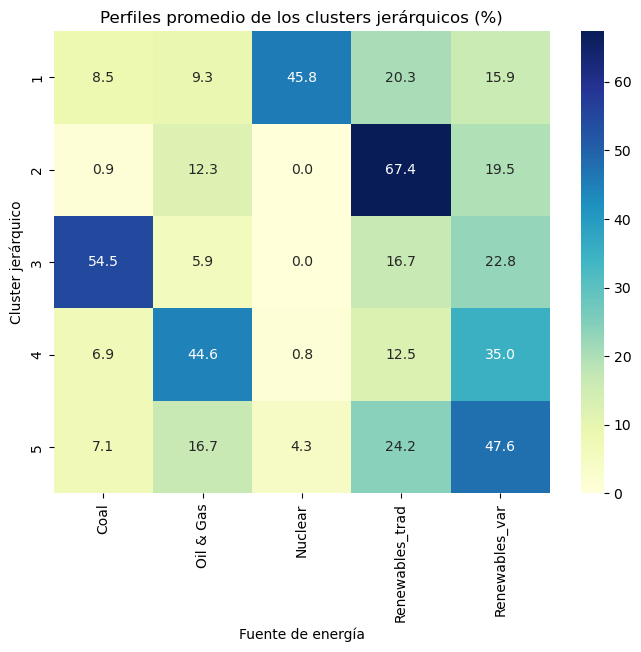

In [102]:
profiles_hier = (
    df_all.drop(columns=["Cluster"], errors="ignore") 
          .assign(Cluster_hier=df_all["Cluster_hier"])
          .groupby("Cluster_hier").mean()
          .sort_index()
)
plt.figure(figsize=(8,6))
sns.heatmap(profiles_hier, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Perfiles promedio de los clusters jerárquicos (%)")
plt.ylabel("Cluster jerárquico")
plt.xlabel("Fuente de energía")
plt.show()

## Comparación de perfiles promedio: K-means vs. Clustering jerárquico

- **Clusters de Carbón**  
  - *K-means (C0):* 45% carbón.  
  - *Jerárquico (C3):* 55% carbón.  
  → Ambos métodos detectan un bloque muy marcado por carbón, aunque el jerárquico lo concentra aún más.
- **Clusters de Renovables tradicionales (hidro/biomasa)**  
  - *K-means (C1):* 62% renovables tradicionales.  
  - *Jerárquico (C2):* 67% renovables tradicionales.  
  → Muy consistentes: se confirma un grupo hidro-dependiente.
- **Clusters nucleares**  
  - *K-means (C2):* 49% nuclear.  
  - *Jerárquico (C1):* 46% nuclear.  
  → Ambos capturan claramente el bloque nuclear.
- **Clusters de Renovables variables (eólica/solar)**  
  - *K-means (C3):* 53% renovables variables.  
  - *Jerárquico (C5):* 48% renovables variables.  
  → Coherentes: destacan un grupo con fuerte penetración de variables.
- **Clusters Oil & Gas**  
  - *K-means (C4):* 41% gas/petróleo + 36% renovables variables.  
  - *Jerárquico (C4):* 45% gas/petróleo + 35% renovables variables.  
  → Ambos coinciden en identificar un cluster fósil–renovable.

**Conclusión:**  
Los dos métodos convergen en la caracterización de los grandes bloques (Carbón, Nuclear, Renovables tradicionales, Renovables variables, Oil & Gas). Las diferencias aparecen en países híbridos o atípicos, pero a nivel de perfiles promedio, la consistencia es muy alta, lo que valida la robustez del análisis.

---
## Síntesis ejecutiva

El análisis de las matrices eléctricas de 21 países de la UE (2023) permitió identificar perfiles energéticos comunes a través de métodos de clustering (K-means y jerárquico). Los resultados convergen en cinco grandes bloques:

- **Carbón:** países con alta dependencia del carbón en su mix eléctrico.  
- **Nuclear:** sistemas con una base sólida de generación nuclear.  
- **Renovables tradicionales:** matrices dominadas por hidroeléctrica y biomasa.  
- **Renovables variables:** países con fuerte penetración de eólica y solar.  
- **Oil & Gas:** sistemas dependientes de gas y petróleo, con integración relevante de renovables.

### Hallazgos clave
- **Consistencia metodológica:** ambos métodos coinciden en la caracterización de los grandes bloques, lo que valida la robustez de los resultados.  
- **Casos híbridos y atípicos:**  
  - *Alemania* pasa de un cluster fósil (K-means) a renovables variables (jerárquico), reflejando mejor su transición. 
  - *Estonia y Polonia* aparecen como un bloque fósil muy marcado en el método jerárquico, lo que resalta su perfil altamente particular dentro del conjunto europeo.
  - *Suecia* aparece como híbrido entre hidro y nuclear, mostrando límites de K-means.  
- **Comparación metodológica:**  
  - *K-means* aporta clusters compactos y fáciles de comunicar.  
  - *Jerárquico* resalta mejor subgrupos y casos atípicos, complementando la interpretación.
- **Diversificación del mix:** la mayoría de los países de la UE presenta matrices eléctricas diversificadas, combinando renovables, nuclear y fósiles.  
- **Dependencia fósil limitada:** son relativamente pocos los países cuya generación eléctrica depende fuertemente de gas y petróleo, lo que parecería reducir la vulnerabilidad del conjunto ante shocks como la crisis de suministro de gas ruso en 2022.  
- **Riesgos focalizados:** los países más expuestos —principalmente **Grecia, Italia, Irlanda y Países Bajos**, con una alta participación de gas y petróleo en su mix eléctrico— requieren estrategias específicas de diversificación y seguridad energética. En contraste, el resto de los países muestra una **menor dependencia directa de hidrocarburos**, lo que sugiere que no todos debieron haber experimentado la misma presión sobre los precios de la electricidad durante la crisis de 2022. Esto refuerza la idea de que el impacto de la volatilidad del gas debería haber sido **heterogéneo** dentro de la UE.

### Impacto de la crisis del gas en la UE-27
Si bien el análisis de clusters muestra que **sólo un conjunto reducido de países (Grecia, Italia, Irlanda y Países Bajos) depende fuertemente del gas y petróleo** para su generación eléctrica, este [**informe de la UE-27**](https://drive.google.com/file/d/1X0Ttpvtd43FUVFGUnAoom7ZYPBBvVRPw/view?usp=sharing) evidencia que el aumento de precios de la electricidad fue generalizado en los Estados miembros durante la crisis de 2022. Esto se explica por la **estructura de formación de precios marginal del mercado eléctrico europeo**, donde el precio mayorista lo determina la última tecnología necesaria para cubrir la demanda. Dado que en muchos momentos esa tecnología fue el **gas natural**, incluso los países con matrices diversificadas vieron cómo sus precios internos se alineaban con la volatilidad del gas importado.


### Conclusión
El uso combinado de ambos métodos permite una visión equilibrada:  
- **K-means** para comunicar perfiles promedio de forma clara.  
- **Jerárquico** para profundizar en la estructura interna y resaltar particularidades.  

En conjunto, el análisis muestra que los sistemas eléctricos europeos se agrupan en bloques energéticos coherentes y diferenciados, con algunos países clave (Alemania o Suecia) que presentan **perfiles híbridos** y requieren un análisis más detallado para comprender su rol en la transición energética.

